## 1. Import Packages
Import essential Python libraries for transfer learning.
- **TensorFlow / Keras**: build and train our neural network.  
- **VGG16**: a DEEP CNN model pre-trained on ImageNet.  
- **ImageDataGenerator**: to load and augment images.

In [20]:
import numpy                   as np
import matplotlib.pyplot       as plt
import tensorflow              as tf
from tensorflow                import keras
from keras.models              import Sequential
from keras.layers              import GlobalAveragePooling2D, Dense
from keras.applications        import VGG16
from keras.applications.vgg16  import preprocess_input, decode_predictions
from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

## 2. Load Dataset and Set Parameters
Define image size, batch size, and data directories.  
- The dataset (cats & dogs) is organized into train/validation folders.  
- `NumTrainableLayers = 0` means all convolutional layers are frozen (no fine-tuning yet).

In [2]:
!git clone https://github.com/ljwg3000/UNT_MEEN.git

Cloning into 'UNT_MEEN'...
remote: Enumerating objects: 7719, done.
remote: Counting objects: 100% (1661/1661), done.
remote: Compressing objects: 100% (1648/1648), done.
remote: Total 7719 (delta 18), reused 1654 (delta 12), pack-reused 6058 (from 1)
Receiving objects: 100% (7719/7719), 827.35 MiB | 14.99 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (5667/5667), done.


In [6]:
# Parameters
IMG_Width, IMG_Height = 224, 224
batch_size = 32
NumTrainableLayers = 0 # Change this to >0 when you want to fine-tune the base model.

# Directories
TrainData_Dir = "/content/UNT_MEEN/AI_tutorial/Dataset_cats_and_dogs/train"
ValidData_Dir = "/content/UNT_MEEN/AI_tutorial/Dataset_cats_and_dogs/validation"

## 3. Data Generators (Augmentation)
Let's create two generators:
- **train_dataGen**: applies random rotations, shifts, zooms, and flips for data augmentation.  
- **valid_dataGen**: only preprocesses validation images.  
This helps the model generalize better with limited data.

In [8]:
# Data Generators
train_dataGen = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   rotation_range = 20,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

valid_dataGen = ImageDataGenerator(preprocessing_function = preprocess_input)

Using `flow_from_directory`, we load images directly from folders.  
- The images are resized to (224, 224).  
- Binary class mode means: cat = 0, dog = 1.  
We now have ready-to-use batches for training and validation.

In [9]:
# Get training and validation dataset for modeling
train_generator = train_dataGen.flow_from_directory(TrainData_Dir,
                                                    target_size = (IMG_Width, IMG_Height),
                                                    batch_size = batch_size,
                                                    class_mode = 'binary')

valid_generator = valid_dataGen.flow_from_directory(ValidData_Dir,
                                                    target_size = (IMG_Width, IMG_Height),
                                                    batch_size = batch_size,
                                                    class_mode = 'binary')

Found 600 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## 4. Load the Pre-Trained Base Model
We load **VGG16** (trained on ImageNet) without the top classifier layers (`include_top=False`).  
- The convolutional base acts as a **feature extractor**.  
- All layers are frozen (`layer.trainable=False`) to keep learned features.  
- You can unfreeze some top layers to fine-tune if needed.

In [14]:
# Load and configure base model
base_model = VGG16(weights = 'imagenet', include_top = False, input_shape = (IMG_Width, IMG_Height, 3))

# Freeze all layers or not
for layer in base_model.layers:
  layer.trainable = False

# Unfreeze last N (feature extraction) layers
if NumTrainableLayers > 0:
  for layer in base_model.layers[-NumTrainableLayers:]:
    layer.trainable = True

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## 5. Build a New Classifier
We stack new fully connected (Dense) layers on top:
- **GlobalAveragePooling2D** converts feature maps into a single vector.  
- Dense(64, 'relu') + Dense(1, 'sigmoid') classify between cat and dog.  
Only these layers are trainable in this step.

In [16]:
# Build our model
model = Sequential([base_model,
                    GlobalAveragePooling2D(),
                    Dense(64, activation = 'relu'),
                    Dense(1, activation = 'sigmoid')])

# Compile
model.compile(optimizer = tf.keras.optimizers.Adam(0.001),
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 6. Train the Model
Train the model with `Augmented Training Dataset`
- We train this model only for `2` epochs.
- Check the training/validation accuracy.

In [19]:
model.fit(train_generator, epochs=2, validation_data = valid_generator)

Epoch 1/2
19/19 ━━━━━━━━━━━━━━━━━━━━ 822s 45s/step - accuracy: 0.9666 - loss: 0.0929 - val_accuracy: 0.9760 - val_loss: 0.0771
Epoch 2/2
19/19 ━━━━━━━━━━━━━━━━━━━━ 822s 45s/step - accuracy: 0.9742 - loss: 0.0577 - val_accuracy: 0.9730 - val_loss: 0.0792


.

.

.

## 🐱 Comparing Pre-Trained VGG16 vs. Fine-Tuned Model

### 1️⃣ Testing the Pre-Trained VGG16 (ImageNet)
- The **original VGG16** model was trained on **ImageNet**, which includes 1,000 everyday object categories.  
- It has never seen our specific dataset (cats vs. dogs).  
- As a result, when we test an ambiguous image (like a hiding gray cat), it often predicts **similar-looking dog breeds** (e.g., husky, malamute).  
- This happens because ImageNet features are **too general**, not specialized for our binary classification task.

*Key takeaway:* Pre-trained models can recognize generic patterns, but not always the exact classes we need.

In [42]:
model_vgg16 = VGG16(weights = 'imagenet')
model_vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

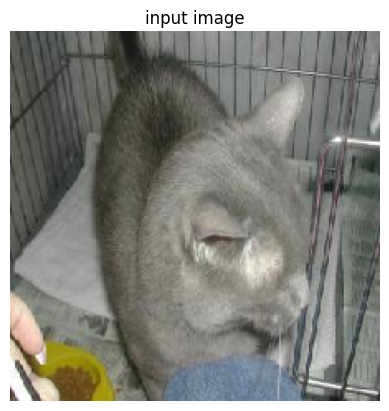

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step
Top 10 predictions:
1. Norwegian_elkhound   (34.35%)
2. Siberian_husky       (10.88%)
3. malamute             (5.84%)
4. Angora               (4.55%)
5. keeshond             (4.33%)
6. shopping_cart        (2.98%)
7. wombat               (2.95%)
8. Eskimo_dog           (2.57%)
9. malinois             (1.87%)
10. Siamese_cat          (1.49%)


In [43]:
# Load and preprocess an image
img_path = "/content/UNT_MEEN/AI_tutorial/Dataset_cats_and_dogs/validation/cats/cat.2342.jpg" # Cat 1
# img_path = "/content/UNT_MEEN/AI_tutorial/Dataset_cats_and_dogs/validation/cats/cat.2337.jpg" # Cat 2
# img_path = "/content/UNT_MEEN/AI_tutorial/Dataset_cats_and_dogs/validation/dogs/dog.2013.jpg" # Dog

img = load_img(img_path, target_size = (IMG_Width, IMG_Height))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Show the input image
plt.imshow(img)
plt.axis("off")
plt.title("input image")
plt.show()

# Make a prediction
prediction = model_vgg16.predict(img_array)
top_preds = decode_predictions(prediction, top=10)[0]

# Print predictions
print("Top 10 predictions:")
for i, (imagenet_id, label, prob) in enumerate(top_preds):
  print(f"{i+1}. {label:20s} ({prob*100:.2f}%)")

### 2️⃣ Testing Our Fine-Tuned Model
- Our **fine-tuned VGG16** reuses ImageNet’s learned features (edges, textures, shapes)  
  and adapts them to our new task using cat/dog-specific data.  
- Even with only a few training epochs, the model quickly learns the **target domain** and predicts correctly.  
- The final layer (Dense sigmoid) outputs probabilities close to 0 → cat, or 1 → dog.  

*Key takeaway:*  
Transfer learning allows the model to **specialize** on our problem while keeping powerful pre-trained knowledge.

In [46]:
model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step


array([[0.26616043]], dtype=float32)

.

.

.

## ⚙️ Training a CNN from Scratch (No Transfer Learning)

### 1️⃣ Building a Simple CNN Model
- We can design a **custom CNN** same as we practiced in ML2-1.  
- Unlike VGG16, this network starts with **random weights** — it has no prior knowledge of image features.  
- The model must learn everything (edges, textures, shapes, etc.) from scratch.




In [39]:
def CNN_model():
    keras.backend.clear_session()

    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(IMG_Width, IMG_Height, 3)))       # Input layer

    model.add(keras.layers.Conv2D(filters = 2, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))    # Convolution layer 1
    model.add(keras.layers.MaxPooling2D(pool_size = (2,2), strides=(2,2)))                                              # Pooling layer 1
    model.add(keras.layers.Conv2D(filters = 4, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))    # Convolution layer 2
    model.add(keras.layers.MaxPooling2D(pool_size = (2,2), strides=(2,2)))                                              # Pooling layer 2

    model.add(keras.layers.Flatten())                                                                                   # Flatten layer
    model.add(keras.layers.Dense(units = 10, activation='relu'))                                                        # Dense layer

    model.add(keras.layers.Dense(units = 1, activation='sigmoid'))                                                      # Output Layer

    model.compile(optimizer= keras.optimizers.Adam(learning_rate = 0.001),
                  loss=keras.losses.CategoricalCrossentropy(),
                  metrics=['accuracy'])
    return model

In [40]:
CnnModel = CNN_model()
CnnModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 2)    │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 4)    │            76 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       125,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,593 (490.60 KB)

 Trainable params: 125,593 (490.60 KB)

 Non-trainable params: 0 (0.00 B)

### 2️⃣ Training for Only 2 Epochs
- When trained for just **2 epochs**, the model cannot generalize well.  
- Accuracy stays near **50%**, meaning it’s basically guessing between cat and dog.  
- This happens because learning low-level and high-level features from zero requires **many more epochs** (often tens or hundreds).

*Key takeaway:*  
Starting from scratch means the model needs **much more data and training time** to learn useful representations.

In [41]:
CnnModel.fit(train_generator, epochs=2, validation_data = valid_generator)

Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4761 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 0.0000e+00
Epoch 2/2
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4782 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 0.0000e+00


### 3️⃣ Comparing with VGG16 Transfer Learning
- The **VGG16 (pre-trained)** model started with ImageNet knowledge —  
  it already “knows” about basic shapes, textures, and animal features.  
- Our scratch CNN, however, had to learn **138 million parameters** (if as deep as VGG16) from zero.  
- Training such a model from scratch would take **hours or even days**, even on GPUs.

*Result:*  
Transfer Learning drastically reduces both **training time** and **data requirements**  
while achieving **high accuracy within just a few epochs**.

---

### ✅ Summary
| Model | Pre-trained? | Epochs | Accuracy | Training Time |
|:------|:--------------|:--------|:-----------|:----------------|
| Custom CNN (from scratch) | ❌ No | 2 | ~50% | Short, but ineffective |
| VGG16 (Transfer Learning) | ✅ Yes (ImageNet) | 2 | ~97% | Short **and** effective |


.

*Final insight:*  
Transfer Learning reuses prior knowledge to make deep learning **faster, smarter, and more efficient** —  
especially when data or time is limited.